In [ ]:
#Research Question
#impact of study time on grades
#In this project, we aim to investigate whether study time influences grades using real-world data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## 1. Data Loading
Load your dataset using Python (CSV or JSON)

In [3]:
df_prev = pd.read_csv("student-por.csv")
df = pd.DataFrame(df_prev)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 2. Data Cleaning
Handle missing values by removing rows or filling values with mean median or mode. 
Explain your choice.

In [8]:
df.isna().sum()


school           0
sex              0
age              0
address          0
famsize          0
Pstatus          0
Medu             0
Fedu             0
Mjob             0
Fjob             0
reason           0
guardian         0
traveltime       0
studytime        0
failures         0
schoolsup        0
famsup           0
paid             0
activities       0
nursery          0
higher           0
internet         0
romantic         0
famrel           0
freetime         0
goout            0
Dalc             0
Walc             0
health           0
absences         0
G1               0
G2               0
G3               0
Average_Grade    0
dtype: int64

In [9]:
#Average grades column
df['Average_Grade'] = round(((df['G1'] + df['G2'] + df['G3']) / 3), 2)

print(df)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

     ... freetime goout  Dalc  Walc  health absence

## 3. Descriptive Statistics
Compute and explain:
- Mean
- Median
- Variance
- Standard deviation
- Group statistics

In [12]:
#all g's refer to grades
#all s's refer to study time
mean_g_total = 0
mean_s = 0
med_g = 0
med_s = 0
var_g = 0
var_s = 0
std_g = 0
std_s = 0
gs_g = 0
gs_s = 0
count = 649

mean_g = 0
count_s = 0

for grade in df['Average_Grade']:
    mean_g += grade
mean_g = mean_g/count


for study in df['studytime']:
    mean_s += study
    count_s += 1
mean_s = round(mean_s/count_s, 2)

med_s = df['studytime'].median(axis=0)
med_g = df['Average_Grade'].median(axis=0)


var_s = round(df['studytime'].var(), 2)
var_g = round(df['Average_Grade'].var(), 2)

std_g = round(df['Average_Grade'].std(), 2)
std_s = round(df['studytime'].std(), 2)



print('Grade Mean:', mean_g)
print('Study Time Mean:', mean_s)
print('Grade Median:', med_g)
print('Study Time Median:', med_s)
print('Grade Variance:', var_g)
print('Study Time Variance', var_s)
print('Grade Standard Deviation:', std_g)
print('Study Time Standard Deviation:', std_s)
a = df.groupby('studytime')['G1'].mean()
print(a)
b = df.groupby('studytime')['G2'].mean()
print(b)
c = df.groupby('studytime')['G3'].mean()
print(c)

Grade Mean: 11.6251155624037
Study Time Mean: 1.93
Grade Median: 11.67
Study Time Median: 2.0
Grade Variance: 8.03
Study Time Variance 0.69
Grade Standard Deviation: 2.83
Study Time Standard Deviation: 0.83
studytime
1    10.504717
2    11.537705
3    12.422680
4    12.771429
Name: G1, dtype: float64
studytime
1    10.702830
2    11.662295
3    12.793814
4    12.628571
Name: G2, dtype: float64
studytime
1    10.844340
2    12.091803
3    13.226804
4    13.057143
Name: G3, dtype: float64


## 4. Data Visualization
Create at least:
- Bar plot
- Histogram
- Scatter plot

All plots must include titles and axis labels.

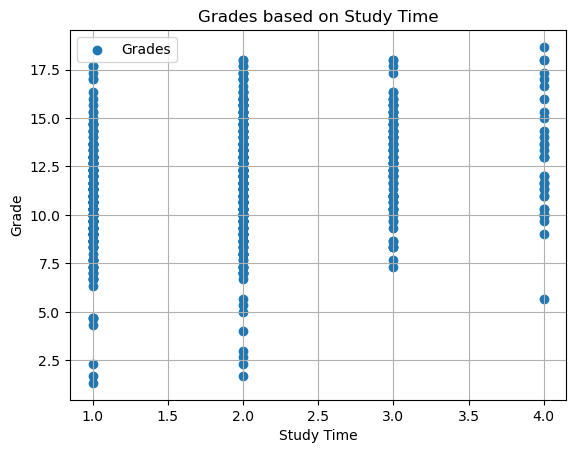

In [13]:
G = np.array(df['Average_Grade'])
ST = np.array(df['studytime'])
plt.scatter(ST, G, label='Grades')
plt.title('Grades based on Study Time')
plt.xlabel('Study Time')
plt.ylabel('Grade')
plt.legend()
plt.grid(True)
plt.show()





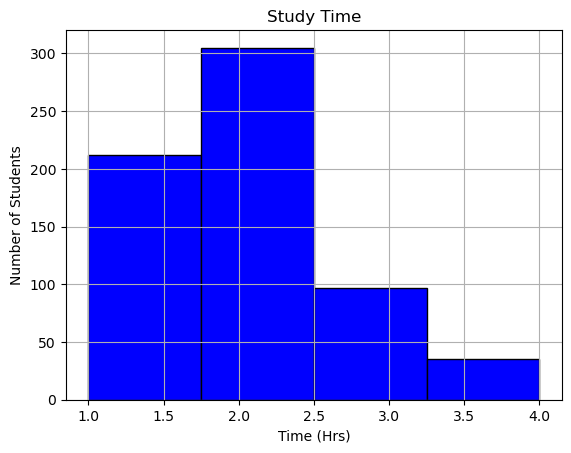

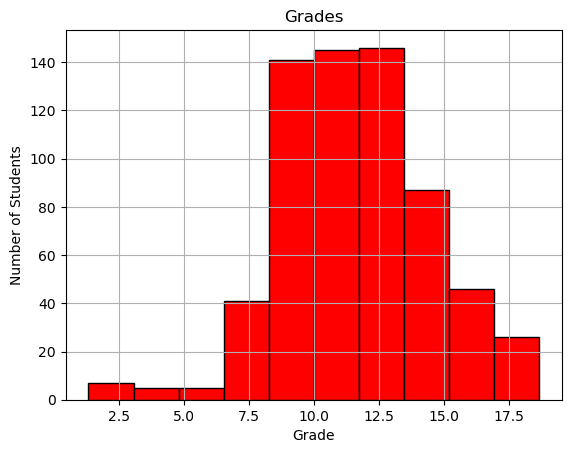

In [14]:
df['studytime'].hist(bins=4, color='blue', edgecolor='black')
plt.title('Study Time')
plt.xlabel('Time (Hrs)')
plt.ylabel('Number of Students')
plt.show()

df['Average_Grade'].hist(color='red', edgecolor='black')
plt.title('Grades')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.show()


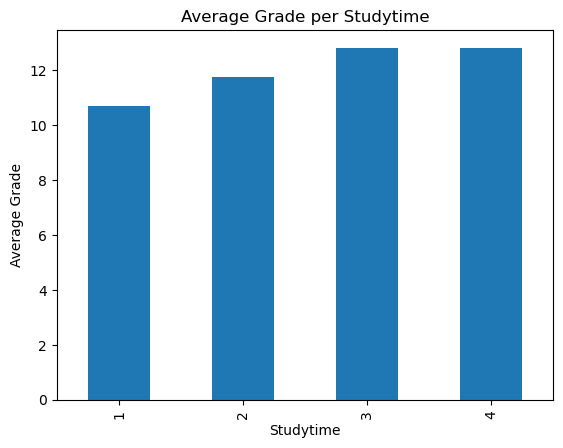

In [33]:
'''
df.plot.bar(x='Average_Grade', y='studytime', stacked=True)
df.plot.bar(x='studytime', y='Average_Grade', stacked=True)
'''

avg_grades = df.groupby('studytime')['Average_Grade'].mean()

avg_grades.plot(kind='bar')
plt.title('Average Grade per Studytime')
plt.xlabel('Studytime')
plt.ylabel('Average Grade')

plt.show()

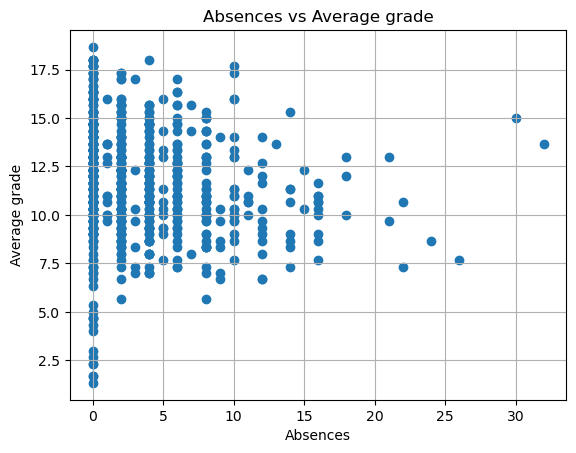

"\nG = np.array(df['Average_Grade'])\nST = np.array(df['absences'])\nplt.scatter(ST, G, label='Grades')\nplt.title('Grades based on Absences')\nplt.xlabel('Absences')\nplt.ylabel('Grade')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [29]:
#scatter
plt.scatter(df['absences'], df['Average_Grade'])
plt.title('Absences vs Average grade')
plt.xlabel('Absences')
plt.ylabel('Average grade')
plt.grid(True)

plt.show()

'''
G = np.array(df['Average_Grade'])
ST = np.array(df['absences'])
plt.scatter(ST, G, label='Grades')
plt.title('Grades based on Absences')
plt.xlabel('Absences')
plt.ylabel('Grade')
plt.legend()
plt.grid(True)
plt.show()
'''




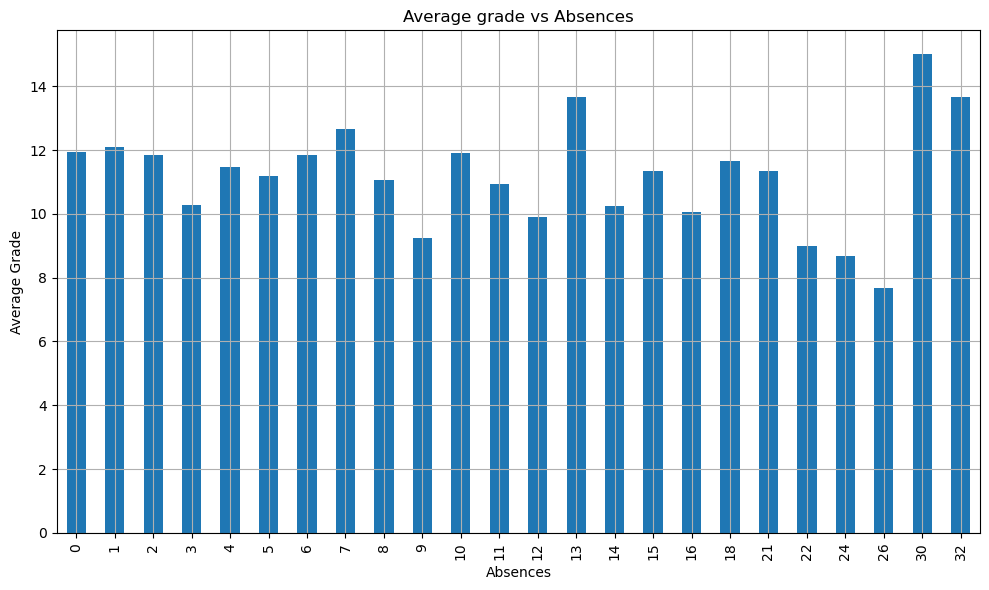

In [30]:
#barplot
grouped = df.groupby('absences')['Average_Grade'].mean()

plt.figure(figsize=(10,6))
grouped.plot(kind='bar')
plt.xlabel('Absences')
plt.ylabel('Average Grade')
plt.title('Average grade vs Absences')

plt.grid(True)

plt.tight_layout()
plt.show()



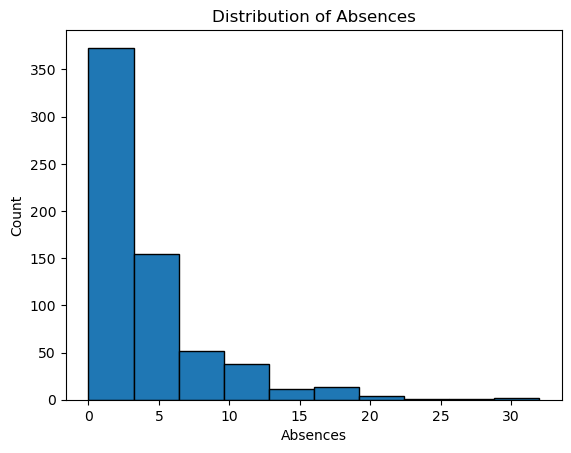

In [32]:
#histogram

plt.hist(df['absences'], bins=10, edgecolor='black')

plt.title('Distribution of Absences')
plt.xlabel('Absences')
plt.ylabel('Count')

plt.show()

## 5. Linear Regression
Use regression to answer a predictive question and explain:
- Inputs (X)
- Output (y)
- Interpretation of results


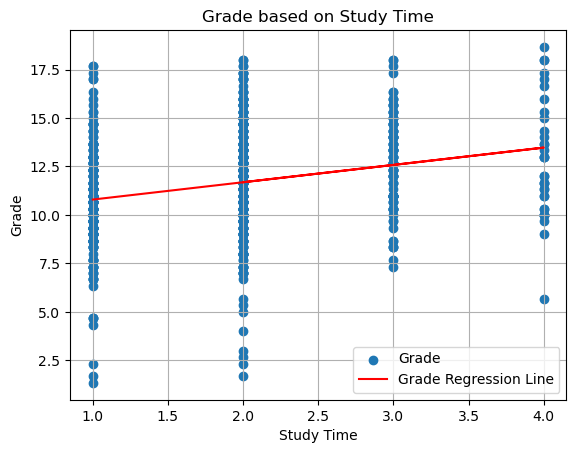

In [149]:
g = np.array(df['Average_Grade'])
st = np.array(df['studytime'])
g_reg = stats.linregress(st, g)

plt.scatter(st, g, label='Grade')
plt.plot(st, g_reg.slope*st+g_reg.intercept, label='Grade Regression Line', color = 'red')
plt.title('Grade based on Study Time')
plt.xlabel('Study Time')
plt.ylabel('Grade')
plt.legend()
plt.grid(True)
plt.show()

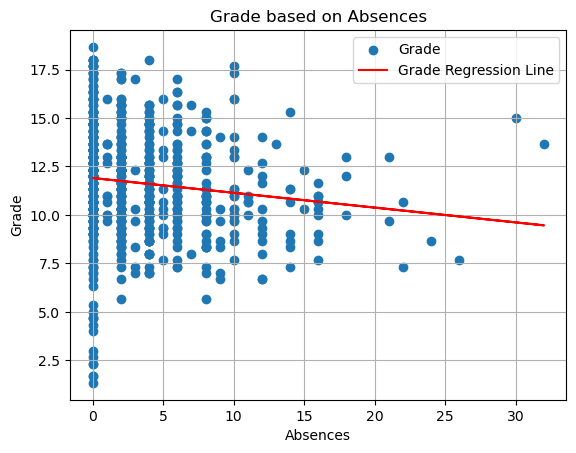

In [34]:
g = np.array(df['Average_Grade'])
st = np.array(df['absences'])
g_reg = stats.linregress(st, g)

plt.scatter(st, g, label='Grade')
plt.plot(st, g_reg.slope*st+g_reg.intercept, label='Grade Regression Line', color = 'red')
plt.title('Grade based on Absences')
plt.xlabel('Absences')
plt.ylabel('Grade')
plt.legend()
plt.grid(True)
plt.show()

## 6. Machine Learning Model
Use one ML model:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

Explain what you predict, model accuracy, and features used.